# Data Exploration - Nasdaq Options Dataset

Looking at the data we used to train the XGBoost model

## Load Libraries

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

%matplotlib inline

## Load Data

In [15]:
FILE_PATH = 'nasdaq_100_data.csv.gz'

print(f"Loading {FILE_PATH}...")
df = pd.read_csv(FILE_PATH, compression='gzip')

# Feature Engineering
# Map Option Type to binary
df['is_call'] = df['optionType'].astype(str).str.upper().apply(lambda x: 1 if 'C' in x or 'CALL' in x else 0)

# Add Risk-Free Rate if missing
if 'r' not in df.columns:
    df['r'] = 0.045

# Calculate Historical Volatility (30-Day Rolling)
if 'sigma' not in df.columns:
    print("Calculating 30-Day Historical Volatility...")
    price_history = df[['date', 'S']].drop_duplicates().sort_values('date').set_index('date')
    price_history['returns'] = np.log(price_history['S'] / price_history['S'].shift(1))
    price_history['sigma'] = price_history['returns'].rolling(window=30).std() * np.sqrt(252)
    price_history['sigma'] = price_history['sigma'].fillna(price_history['sigma'].mean())
    df = df.merge(price_history[['sigma']], on='date', how='left')

# Calculate Moneyness (S/K ratio)
df['moneyness'] = df['S'] / df['K']

# Categorize Moneyness
def categorize_moneyness(row):
    m = row['moneyness']
    is_call = row['is_call']
    
    if is_call == 1:  # Call option
        if m > 1.02:
            return 'ITM'  # In-the-money
        elif m < 0.98:
            return 'OTM'  # Out-of-the-money
        else:
            return 'ATM'  # At-the-money
    else:  # Put option
        if m < 0.98:
            return 'ITM'
        elif m > 1.02:
            return 'OTM'
        else:
            return 'ATM'

df['moneyness_category'] = df.apply(categorize_moneyness, axis=1)

# Convert time to days
df['T_days'] = df['T'] * 365

print(f"Loaded {len(df):,} rows")
print(f"Columns: {df.shape[1]}")

Loading nasdaq_100_data.csv.gz...
Calculating 30-Day Historical Volatility...
Loaded 1,429,136 rows
Columns: 15


## Basic Info

In [16]:
# Look at the data
df.head()

,code,date,optionType,K,marketPrice,expiration,date_obj,S,T,moneyness,is_call,r,sigma,moneyness_category,T_days
0,CME_MNQ_H2021_S,2020-12-28,P,10650.0,128.00,2021-03-19,2020-12-28,12832.75,0.221918,1.204953,0,0.045,0.214351,OTM,81.0
1,CME_MNQ_H2021_S,2020-12-28,P,11330.0,207.50,2021-03-19,2020-12-28,12832.75,0.221918,1.132635,0,0.045,0.214351,OTM,81.0
2,CME_MNQ_H2021_S,2020-12-28,C,11620.0,1466.50,2021-03-19,2020-12-28,12832.75,0.221918,1.104367,1,0.045,0.214351,ITM,81.0
3,CME_MNQ_H2021_S,2020-12-28,P,11010.0,165.75,2021-03-19,2020-12-28,12832.75,0.221918,1.165554,0,0.045,0.214351,OTM,81.0
4,CME_MNQ_H2021_S,2020-12-28,C,13480.0,260.75,2021-03-19,2020-12-28,12832.75,0.221918,0.951984,1,0.045,0.214351,OTM,81.0


In [17]:
# Stats
df.describe()

,K,marketPrice,S,T,moneyness,is_call,r,sigma,T_days
count,1.429136e+06,1.429136e+06,1.429136e+06,1.429136e+06,1.429136e+06,1.429136e+06,1.429136e+06,1.429136e+06,1.429136e+06
mean,1.557286e+04,1.196392e+03,1.545514e+04,2.652179e-01,1.016663e+00,4.978700e-01,4.500000e-02,2.134604e-01,9.680455e+01
std,4.136388e+03,1.417137e+03,3.084196e+03,2.415461e-01,1.486426e-01,4.999956e-01,1.284265e-12,8.371405e-02,8.816432e+01
min,8.300000e+03,1.000000e-01,1.072800e+04,2.191781e-02,7.000000e-01,0.000000e+00,4.500000e-02,8.221425e-02,8.000000e+00
25%,1.275000e+04,1.222500e+02,1.339550e+04,9.589041e-02,9.108152e-01,0.000000e+00,4.500000e-02,1.570833e-01,3.500000e+01
50%,1.463000e+04,6.325000e+02,1.480225e+04,1.780822e-01,1.014332e+00,0.000000e+00,4.500000e-02,1.923740e-01,6.500000e+01
75%,1.725000e+04,1.876250e+03,1.627575e+04,3.698630e-01,1.133396e+00,1.000000e+00,4.500000e-02,2.624567e-01,1.350000e+02
max,3.750000e+04,1.099600e+04,2.626250e+04,1.000000e+00,1.300000e+00,1.000000e+00,4.500000e-02,5.159746e-01,3.650000e+02


## Distributions

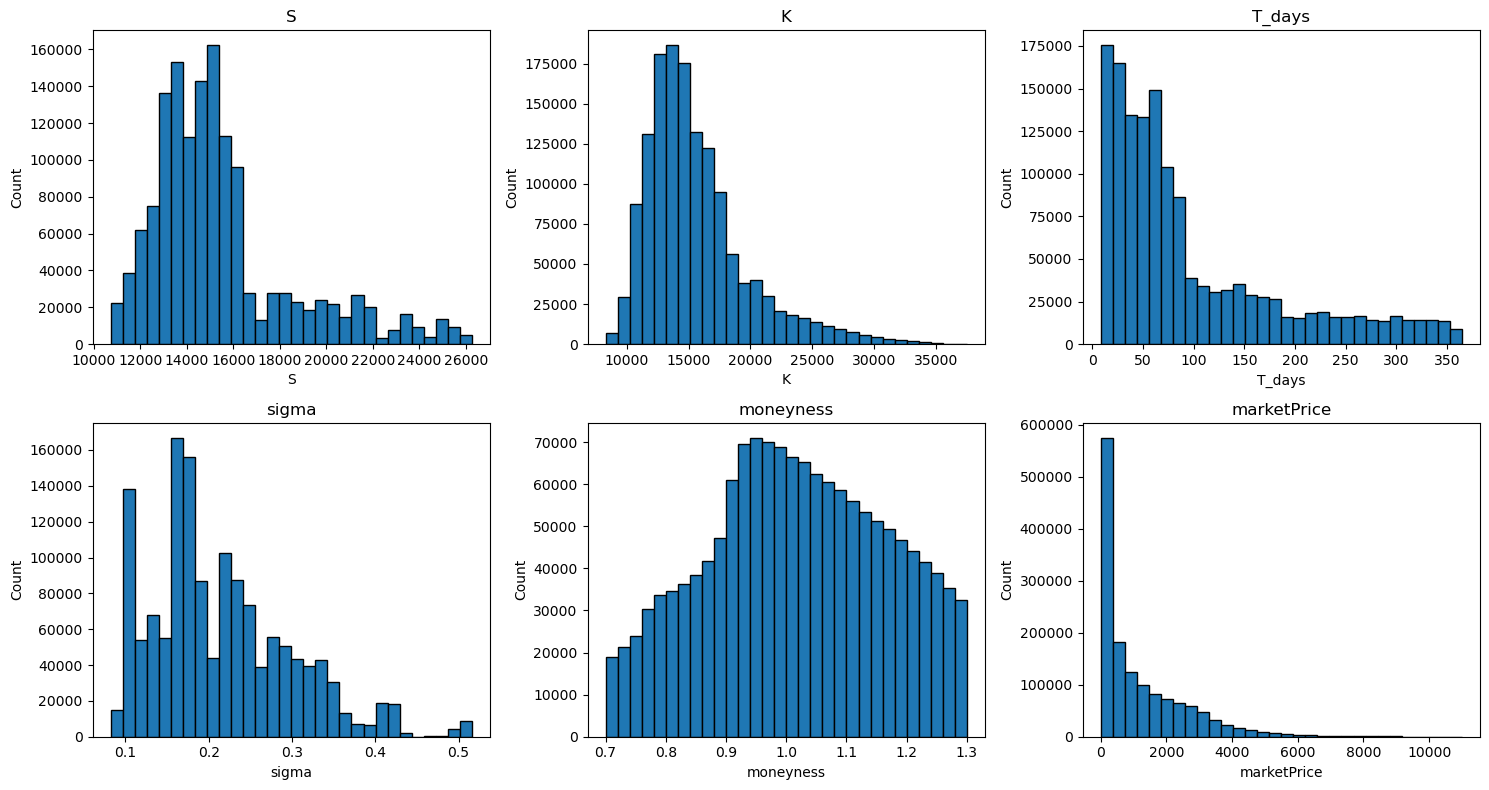

In [6]:
# Plot distributions
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

features = ['S', 'K', 'T_days', 'sigma', 'moneyness', 'marketPrice']

for idx, feature in enumerate(features):
    row = idx // 3
    col = idx % 3
    axes[row, col].hist(df[feature], bins=30, edgecolor='black')
    axes[row, col].set_title(feature)
    axes[row, col].set_xlabel(feature)
    axes[row, col].set_ylabel('Count')

plt.tight_layout()
plt.show()

## Calls vs Puts

is_call
0    717612
1    711524
Name: count, dtype: int64


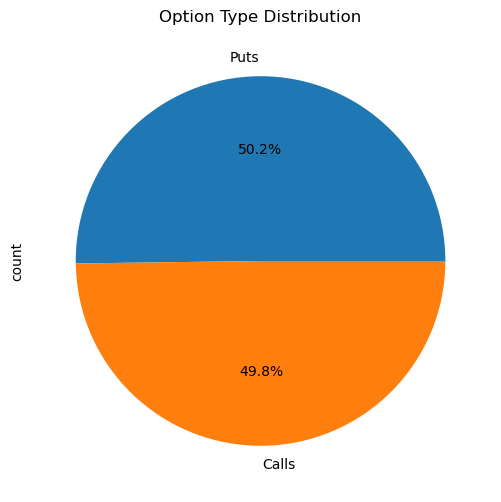

In [7]:
# How many calls vs puts?
print(df['is_call'].value_counts())

# Simple pie chart
plt.figure(figsize=(8, 6))
df['is_call'].value_counts().plot(kind='pie', labels=['Puts', 'Calls'], autopct='%1.1f%%')
plt.title('Option Type Distribution')
plt.show()

## Moneyness

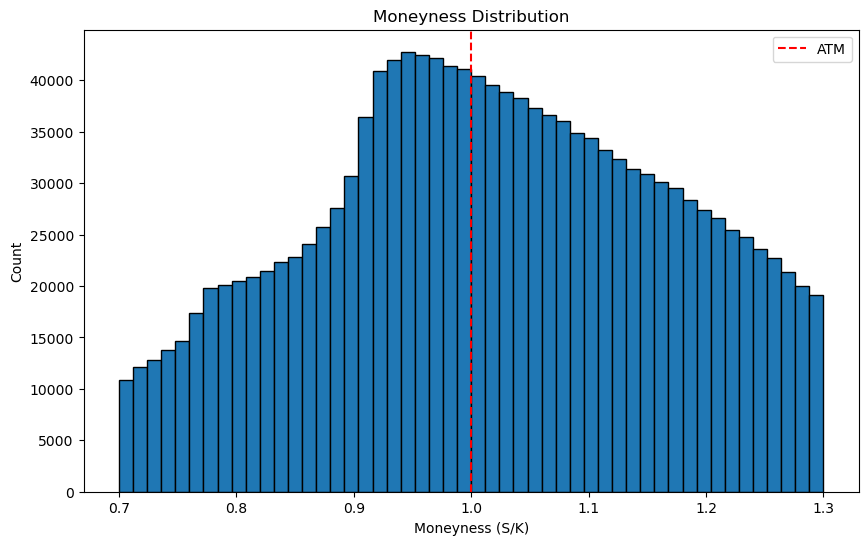

moneyness_category
ITM    649931
OTM    643843
ATM    135362
Name: count, dtype: int64


In [8]:
# Plot moneyness distribution
plt.figure(figsize=(10, 6))
plt.hist(df['moneyness'], bins=50, edgecolor='black')
plt.axvline(x=1.0, color='red', linestyle='--', label='ATM')
plt.xlabel('Moneyness (S/K)')
plt.ylabel('Count')
plt.title('Moneyness Distribution')
plt.legend()
plt.show()

# Check categories
print(df['moneyness_category'].value_counts())

## Time to Expiration

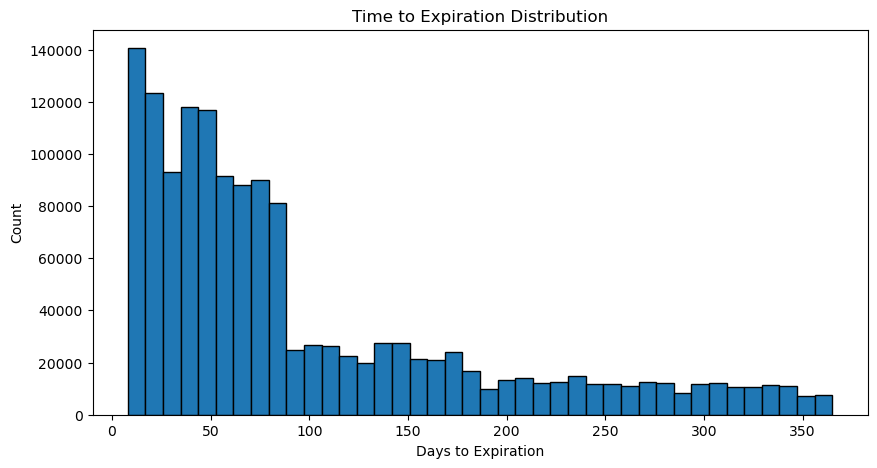

Mean: 96.8 days
Median: 65.0 days


In [9]:
# Plot time to expiration
plt.figure(figsize=(10, 5))
plt.hist(df['T_days'], bins=40, edgecolor='black')
plt.xlabel('Days to Expiration')
plt.ylabel('Count')
plt.title('Time to Expiration Distribution')
plt.show()

print(f"Mean: {df['T_days'].mean():.1f} days")
print(f"Median: {df['T_days'].median():.1f} days")

## Volatility

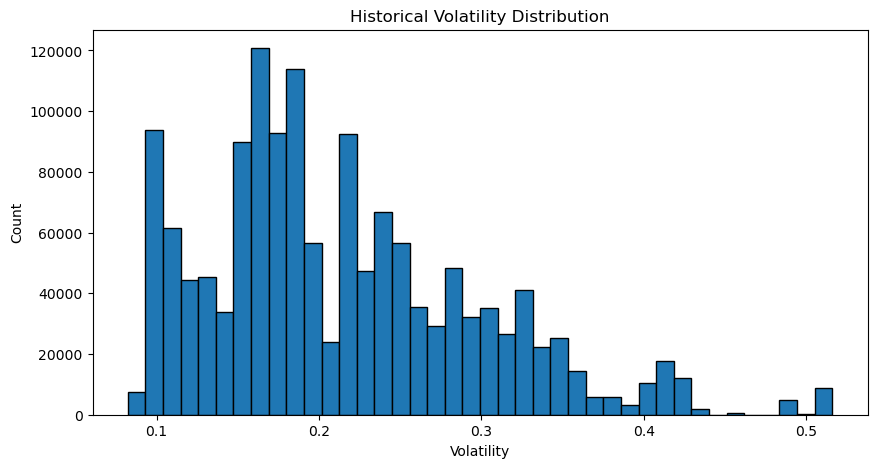

Mean: 0.213
Median: 0.192


In [10]:
# Check volatility distribution
plt.figure(figsize=(10, 5))
plt.hist(df['sigma'], bins=40, edgecolor='black')
plt.xlabel('Volatility')
plt.ylabel('Count')
plt.title('Historical Volatility Distribution')
plt.show()

print(f"Mean: {df['sigma'].mean():.3f}")
print(f"Median: {df['sigma'].median():.3f}")

## Market Prices

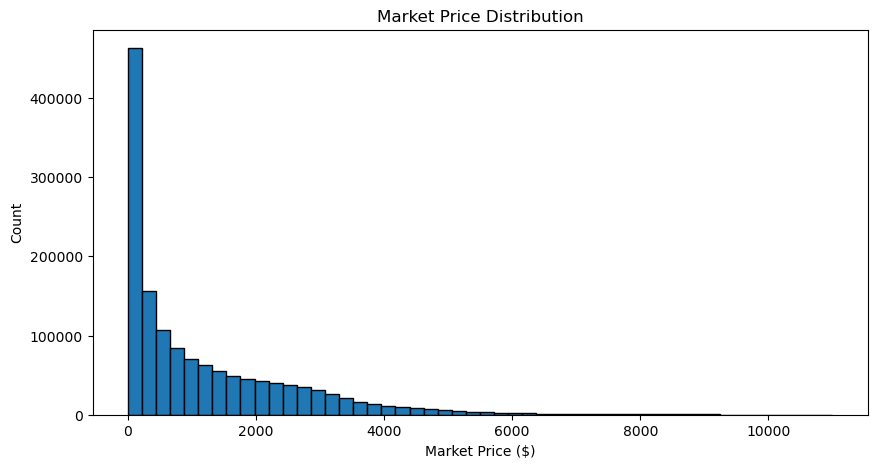

Mean price: $1196.39
Median price: $632.50


In [11]:
# Price distribution
plt.figure(figsize=(10, 5))
plt.hist(df['marketPrice'], bins=50, edgecolor='black')
plt.xlabel('Market Price ($)')
plt.ylabel('Count')
plt.title('Market Price Distribution')
plt.show()

print(f"Mean price: ${df['marketPrice'].mean():.2f}")
print(f"Median price: ${df['marketPrice'].median():.2f}")

## Correlation Matrix

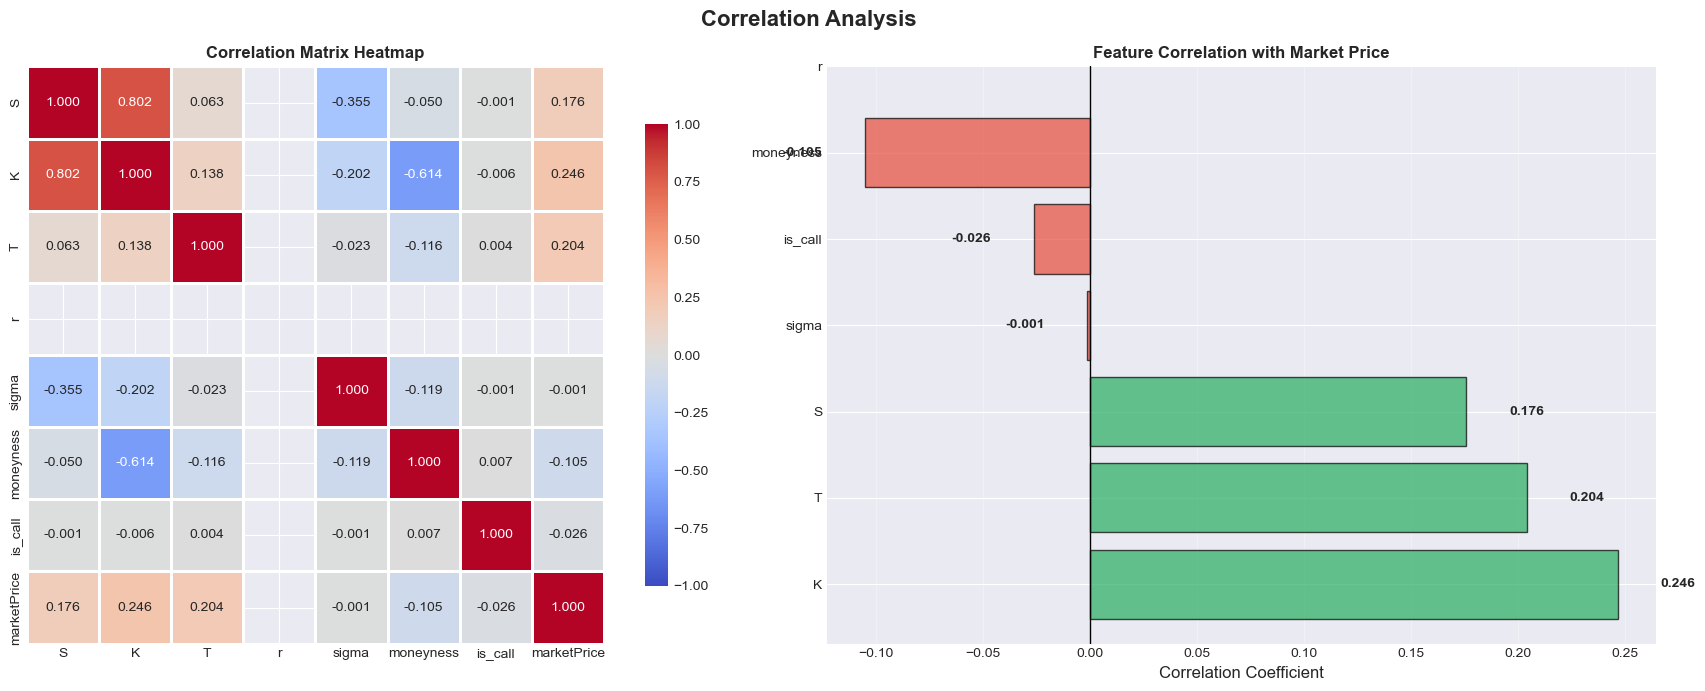


CORRELATION WITH MARKET PRICE
K              :  0.2465  Positive (Weak)
T              :  0.2040  Positive (Weak)
S              :  0.1758  Positive (Weak)
sigma          : -0.0011  Negative (Weak)
is_call        : -0.0261  Negative (Weak)
moneyness      : -0.1051  Negative (Weak)
r              :     nan  Negative (Weak)


In [ ]:
# Check correlations
corr = df[['S', 'K', 'T', 'sigma', 'moneyness', 'marketPrice']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr, annot=True, cmap='coolwarm', center=0)
plt.title('Feature Correlations')
plt.show()

## Price vs Features

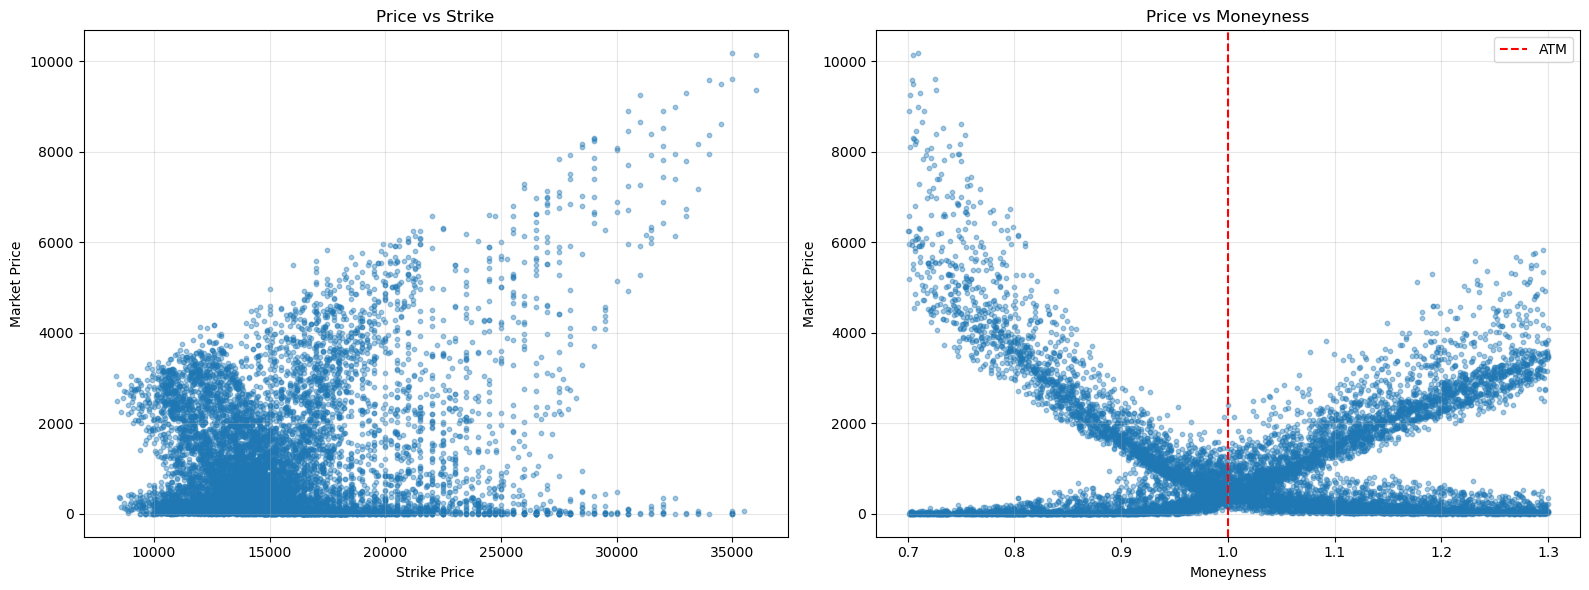

In [ ]:
# Some scatter plots, using sample to avoid overcrowding
sample_df = df.sample(n=min(10000, len(df)), random_state=42)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Price vs Strike
axes[0].scatter(sample_df['K'], sample_df['marketPrice'], alpha=0.4, s=10)
axes[0].set_xlabel('Strike Price')
axes[0].set_ylabel('Market Price')
axes[0].set_title('Price vs Strike')
axes[0].grid(True, alpha=0.3)

# Price vs Moneyness
axes[1].scatter(sample_df['moneyness'], sample_df['marketPrice'], alpha=0.4, s=10)
axes[1].axvline(x=1.0, color='red', linestyle='--', label='ATM')
axes[1].set_xlabel('Moneyness')
axes[1].set_ylabel('Market Price')
axes[1].set_title('Price vs Moneyness')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()